# Modelo de Predicción Lineal - 5000 Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats
%matplotlib inline

## 1. Importacion de los 5000 Datos

In [13]:
df = pd.read_csv("Edad_Salario_5000.csv")
df['Salario (MXN)'] = df['Salario (MXN)'].replace({',': ''}, regex=True).astype(float)
df['Edad (años)'] = pd.to_numeric(df['Edad (años)'])
df.columns = ['Edad', 'Salario']
print(df.head())

   Edad   Salario
0    60  65792.82
1    50  50439.57
2    36  35985.09
3    64  62701.75
4    29  26428.34


## 2. Dispersión de los datos

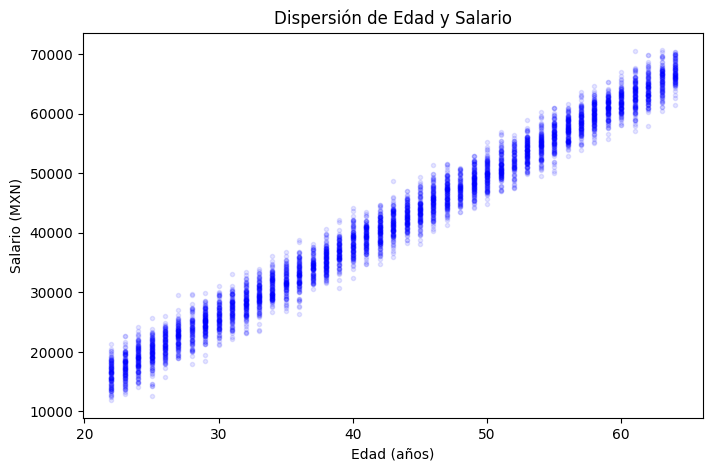

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(df['Edad'], df['Salario'], "b.", alpha=0.1)
plt.xlabel("Edad (años)")
plt.ylabel("Salario (MXN)")
plt.title("Dispersión de Edad y Salario")
plt.show()

## 3. Coeficiente de correlación

In [47]:
r, p_valor = stats.pearsonr(df['Edad'], df['Salario'])
print(f'Coeficiente de correlación de Pearson (r): {r:.6f}')
modelo = LinearRegression()

Coeficiente de correlación de Pearson (r): 0.990979


## 4. Theta 0 y Theta 1

In [55]:
modelo = LinearRegression()
modelo.fit(df['Edad'].values.reshape(-1,1), df['Salario'].values)
theta0 = modelo.intercept_
theta1 = modelo.coef_[0]
print(f'Theta 0 (intercepto): {theta0:,.2f}')
print(f'Theta 1 (pendiente):  {theta1:,.4f}')
print(f'Función: h(x) = {theta1:.2f}·x + {theta0:,.2f}')

Theta 0 (intercepto): -10,107.60
Theta 1 (pendiente):  1,202.5366
Función: h(x) = 1202.54·x + -10,107.60


## 5. Modelo sobre los datos

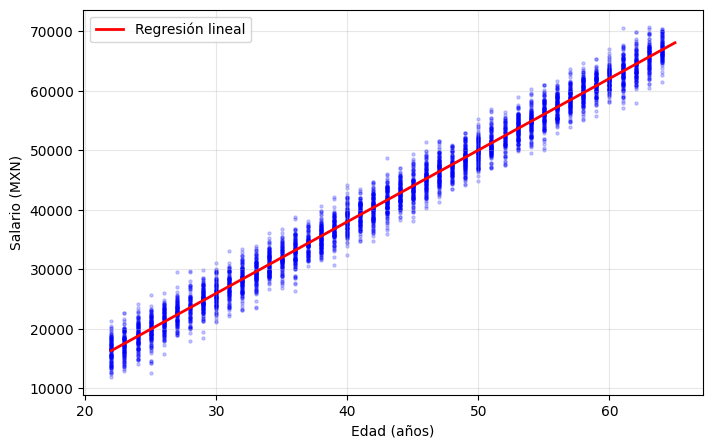

In [53]:
X_line = np.linspace(22, 65, 200).reshape(-1,1)
y_line = modelo.predict(X_line)
plt.figure(figsize=(8,5))
plt.scatter(df['Edad'], df['Salario'], alpha=0.2, s=5, color='blue')
plt.plot(X_line, y_line, 'r-', lw=2, label='Regresión lineal')
plt.xlabel('Edad (años)'); plt.ylabel('Salario (MXN)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Predicciones

In [71]:
modelo.predict([[45]])[0]
pred = modelo.predict([[edad_x]])[0]
print(f'Edad {edad_x} años → Salario estimado: ${pred:,.2f} MXN')

Edad 45 años → Salario estimado: $44,006.54 MXN


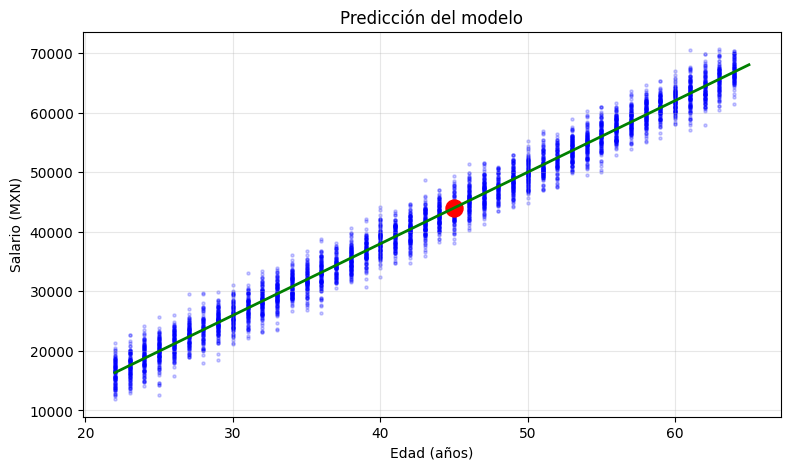

In [75]:
pred_45 = modelo.predict([[45]])[0]
plt.figure(figsize=(9,5))
plt.scatter(df['Edad'], df['Salario'], alpha=0.2, s=5, color='blue')
plt.plot(X_line, y_line, 'g-', lw=2)
plt.scatter([45], [pred_45], color='red', s=150)
plt.xlabel('Edad (años)')
plt.ylabel('Salario (MXN)')
plt.title('Predicción del modelo')
plt.grid(alpha=0.3)
plt.show()